正如之前已经说过，这个文件并不旨在提升预测效果，而只是作为一个搭建模型的示例。

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
import tensorflow as tf

from tensorflow import keras

print(tf.__version__)
print(sys.version_info)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)

2025-05-25 20:23:57.676547: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-25 20:23:57.677367: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-25 20:23:57.680223: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-25 20:23:57.687275: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748175837.699178   31877 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748175837.70

2.19.0
sys.version_info(major=3, minor=11, micro=2, releaselevel='final', serial=0)
matplotlib 3.10.3
numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1
tensorflow 2.19.0
keras._tf_keras.keras 3.9.2


In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
print(housing.DESCR)
print(housing.data.shape)
print(housing.target.shape)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
from sklearn.model_selection import train_test_split

x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state = 7)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_all, y_train_all, random_state = 11)
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)
print(x_test.shape, y_test.shape)


(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)
x_test_scaled = scaler.transform(x_test)

![tf12](./tf12.svg)

In [5]:
# 多输出
input_wide = keras.layers.Input(shape=[5])
input_deep = keras.layers.Input(shape=[6])
hidden1 = keras.layers.Dense(30, activation='relu')(input_deep)
hidden2 = keras.layers.Dense(30, activation='relu')(hidden1)
concat = keras.layers.concatenate([input_wide, hidden2])
output = keras.layers.Dense(1)(concat)
# 多的输出，是使用 hidden2 作为一个输入，只用 deep 做预测
output2 = keras.layers.Dense(1)(hidden2)
model = keras.models.Model(inputs = [input_wide, input_deep],
                           outputs = [output, output2])
        
model.compile(loss="mean_squared_error", optimizer="sgd")
callbacks = [keras.callbacks.EarlyStopping(
    patience=5, min_delta=1e-3)]
model.summary()

2025-05-25 20:23:59.146074: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        210 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 35)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         36 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         31 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,207 (4.71 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
x_train_scaled_wide = x_train_scaled[:, :5]
x_train_scaled_deep = x_train_scaled[:, 2:]
x_valid_scaled_wide = x_valid_scaled[:, :5]
x_valid_scaled_deep = x_valid_scaled[:, 2:]
x_test_scaled_wide = x_test_scaled[:, :5]
x_test_scaled_deep = x_test_scaled[:, 2:]

#因为有多个output，所以需要有多个y
history = model.fit([x_train_scaled_wide, x_train_scaled_deep],
                    [y_train, y_train],  # 这里随意复制了一份。这个文件只是展示模型的搭建过程
                    validation_data = (
                        [x_valid_scaled_wide, x_valid_scaled_deep],
                        [y_valid, y_valid]),
                    epochs = 100,
                    callbacks = callbacks)

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - dense_2_loss: 1.3520 - dense_3_loss: 1.6886 - loss: 3.0407 - val_dense_2_loss: 0.5293 - val_dense_3_loss: 0.7289 - val_loss: 1.2584
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_2_loss: 0.5017 - dense_3_loss: 0.6768 - loss: 1.1785 - val_dense_2_loss: 0.4539 - val_dense_3_loss: 0.6065 - val_loss: 1.0604
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_2_loss: 0.4473 - dense_3_loss: 0.5840 - loss: 1.0313 - val_dense_2_loss: 0.4385 - val_dense_3_loss: 0.5690 - val_loss: 1.0075
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_2_loss: 0.4070 - dense_3_loss: 0.5229 - loss: 0.9299 - val_dense_2_loss: 0.4723 - val_dense_3_loss: 0.5566 - val_loss: 1.0290
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_2_loss: 0.4142 - dense_3_loss: 0.5187 - loss: 0.9329 - val_dense_2_loss: 0.4451 - val_dense_3_loss: 0.5188 - val_loss: 0.9641
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - dense_2_lo

In [7]:
print(history.history)

{'dense_2_loss': [0.8750606775283813, 0.47555553913116455, 0.42866232991218567, 0.41795632243156433, 0.39987418055534363, 0.3884839415550232, 0.3817104697227478, 0.37053027749061584, 0.3645259141921997, 0.3582659363746643, 0.3574519157409668, 0.36333152651786804, 0.37055355310440063, 0.34506845474243164, 0.3469255268573761, 0.34176918864250183, 0.3418794572353363, 0.33969640731811523, 0.33982133865356445, 0.3356732130050659, 0.3356601297855377, 0.33344894647598267, 0.3347707986831665, 0.33243855834007263, 0.3310554325580597, 0.3274807333946228, 0.3280264437198639], 'dense_3_loss': [1.1194827556610107, 0.6376160979270935, 0.5598995685577393, 0.5233355760574341, 0.49501824378967285, 0.47369667887687683, 0.4605056345462799, 0.4477576017379761, 0.43404537439346313, 0.42730069160461426, 0.422039657831192, 0.4214684069156647, 0.4179881811141968, 0.4114517271518707, 0.40958449244499207, 0.4044329524040222, 0.40480828285217285, 0.4007512032985687, 0.39895865321159363, 0.39692577719688416, 0.39

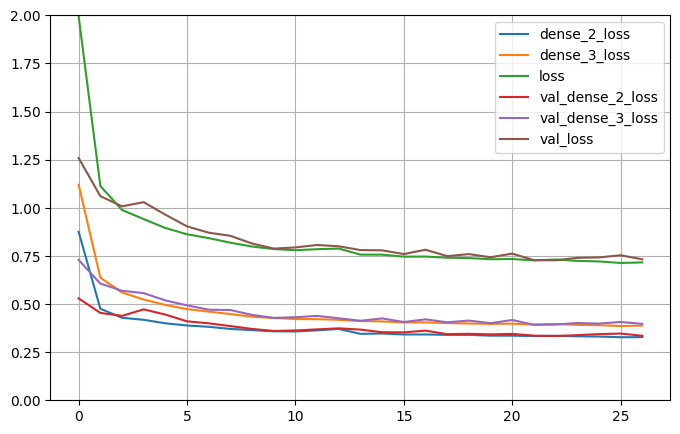

In [8]:
def plot_learning_curves(history):
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 2)
    plt.show()
plot_learning_curves(history)

In [9]:
model.evaluate([x_test_scaled_wide, x_test_scaled_deep],
               [y_test, y_test], verbose=0)

[0.7208459377288818, 0.33553948998451233, 0.387749582529068]